1. loading coordinates, getting uvw, fringe pattern
2. effect of ignoring w term
3. rotation synthesis
4. Fringe rate and beamforming
5. effect of bandwidth

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import radio_tools as rt
import astropy.units as u

we need to know where our baseline vector points, and where the source points.

so I need position of my antenna on earth, and position of the source on the sky.

First let's load antenna positions. Often they're specified in two different ways. 
1. Location on a horizontal grid with respect to some reference point (or reference antenna.) Common for many planar arrays. Imagine taking a ruler and literally measuring distance along the ground. Or may be use laser ranging.
2. For much bigger arrays, in LBI and VLBI, that's not possible. So the antenna positions will be specified using Geodetic coordinates, i.e. latitude, longitude, and elevation or geocentric coordinates x,y,z where x is Greenwich and z is north pole. These are usually measured with very high precision using fancy GPS surveying technqiues like RTK/PPK and/or PPP.

Astronomical sources are often specified in the International Celestial Refernce System using Right Ascension (RA) and Declination (Dec).

Using these two pieces of information we can calculate what the differential light travel time to any pair of antennas (baseline) is.

In [2]:
#Let's look at HERA, specified using distance from reference location.
hera = np.genfromtxt(
    "hera_ant_pos.csv",
    delimiter=",",
    names=True,
    dtype=None,
    encoding="utf-8"
)
hera_xyz = np.asarray([hera['x'],hera['y'],hera['z']]).T.copy() # xyz along columns
#print(hera["x"], hera["y"], hera["z"])
#Let's also load the reference location for these antennas, which will be useful later.
hera_ref = EarthLocation.from_geodetic(lat='−30.72152612068925°', lon='21.42830382686301°',height='1051.69 m')

In [3]:
# we'd now like to generate antenna locations in ENU system centered at the reference location. 
# A good trick for quick calculations is as follows
# This assumes a spherical Earth (will be relevant later.)

up=hera_ref.itrs.cartesian.xyz #that's a vector up thru the ref
up=up/np.sqrt(up@up) #unit vector now

# [1,0,0] = lon = 0 is greenwich, with east +ve and west -ve. So local east vector is just 
# [0,1,0] rotated by longitude
ea=np.asarray([-np.sin(hera_ref.lon.rad), np.cos(hera_ref.lon.rad), 0]) 

#and north is finally just the cross product in a right handed coord. system.
nr=np.cross(up,ea)

mat = np.vstack([ea,nr,up]).T
hera_enu_quick = hera_xyz@mat

In [5]:
#let's also get it the proper way without assuming a spherical earth.
hera_enu = rt.itrs_to_enu(hera_xyz, hera_ref.lat.deg, hera_ref.lon.deg)

Text(0, 0.5, 'north (m)')

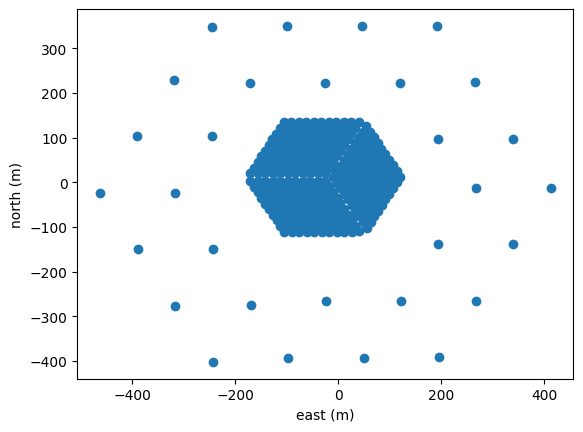

In [6]:
plt.scatter(hera_enu[:,0],hera_enu[:,1])
plt.xlabel("east (m)")
plt.ylabel("north (m)")

In [7]:
print("error in proper vs quick ENU calc", np.std(hera_enu-hera_enu_quick), "m")
print("Where on Earth will this matter?")

error in proper vs quick ENU calc 0.16714423340585227 m
Where on Earth will this matter?


In [8]:
# Let's generate baselines now. There's gonna be a LOT of them. How many?
nant = hera_xyz.shape[0]
nbl = nant * (nant-1)//2
print("num bl is", nbl)

# how to quickly get baselines the numpy vectorized way? laziness is good.
# baselines are just the upper triangle of a nant x nant array
ix = np.triu_indices(nant,k=1) #offset of 1 since main diagonal is autos
print(ix)

num bl is 61075
(array([  0,   0,   0, ..., 347, 347, 348], shape=(61075,)), array([  1,   2,   3, ..., 348, 349, 349], shape=(61075,)))


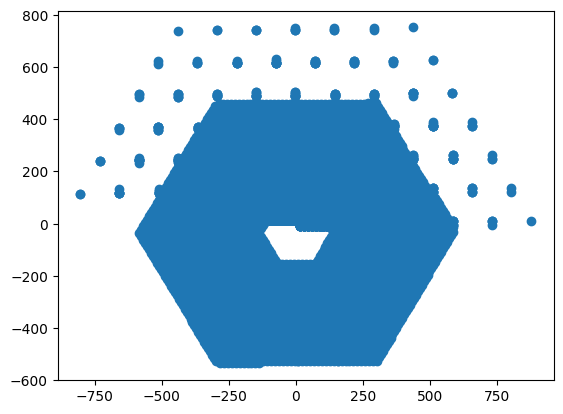

In [9]:
hera_bl_enu = hera_enu[ix[1]]-hera_enu[ix[0]] #and...done!
#let's plot the baselines

plt.scatter(hera_bl_enu[:,0], hera_bl_enu[:,1]) #only upper triangle, all unique pairs

In [10]:
# Let's say it's operating at 150 MHz, and each dish is 14 m wide.
# what's the FoV of one dish, and what's the rough resolution of the array?

lm = 3e8/150e6 #m
d = 14 #m dish size
max_bl = np.max(np.sqrt(np.sum(hera_bl_enu**2,axis=1)))
res = lm/max_bl #max baseline
fov = lm/d

print(f"Synth. beam res\t: {np.rad2deg(res)*60:4.2f} arcmin\nFOV\t\t: {np.rad2deg(fov):4.2f} deg")

Synth. beam res	: 7.84 arcmin
FOV		: 8.19 deg


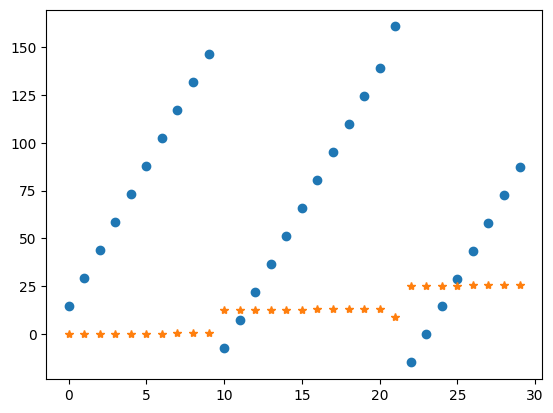

In [101]:
plt.plot(hera_bl_enu[:30,0],ls='',marker='o')
plt.plot(hera_bl_enu[:30,1],ls='',marker='*')

In [99]:
np.where((np.abs(hera_bl_enu[:,1])<100)&(np.abs(hera_bl_enu[:,0])<1))

(array([   23,    51,    83,   372,   400,   432,   720,   748,   780,
         1067,  1095,  1127,  1413,  1441,  1473,  1758,  1786,  1818,
         2102,  2130,  2162,  2445,  2473,  2505,  2787,  2815,  2864,
         3128,  3171,  3205,  3481,  3511,  3545,  3809,  3839,  3873,
         4147,  4177,  4211,  4484,  4514,  4548,  4820,  4850,  4884,
         5155,  5185,  5219,  5489,  5519,  5553,  5822,  5852,  5886,
         6154,  6184,  6218,  6485,  6515,  6567,  6815,  6861,  6897,
         7158,  7190,  7226,  7472,  7502,  7536,  7801,  7833,  7869,
         8127,  8159,  8195,  8452,  8484,  8520,  8776,  8808,  8844,
         9099,  9131,  9167,  9421,  9453,  9489,  9742,  9774,  9810,
        10062, 10094, 10130, 10381, 10413, 10468, 10699, 10748, 10786,
        11031, 11065, 11103, 11332, 11364, 11400, 11647, 11679, 11715,
        11963, 11997, 12035, 12055, 12276, 12310, 12348, 12368, 12588,
        12622, 12660, 12680, 12899, 12933, 12971, 12991, 13209, 13243,
      

In [103]:
hera_bl_enu[5519]

array([-0.19326754, 50.60720945, -0.41942351])

In [49]:
hp.nside2resol(nside,arcmin=True)

np.float64(13.741945647269624)

In [104]:
# before we make PSFs let's first see what the interferometer sees if I just turn it ON.

# to answer that, we must answer what geometrical delay does any baselines measure?
# let's try to look at Cen A
# Since our baselines are in topocentric (ENU) system, we need to know where the source is on the sky in that system.
# Remember: origin is at the reference position. 

# a small exercise

nside=512
npix=hp.nside2npix(nside)
res=hp.nside2resol(nside,arcmin=True)
co_dec,ra=hp.pix2ang(nside,np.arange(npix))
dec=np.pi/2-co_dec
tstart = 1753200150 #random datetime, you can choose your favorite, just make sure the source is risen!
obstime=Time(tstart,format="unix",scale="utc")
src = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
azalt =src.transform_to(AltAz(location=hera_ref,obstime=obstime))
setsrc=azalt.alt.deg<0
delays = rt.geo_delay_from_enu(hera_bl_enu[[5,5519],:],azalt.az.rad,azalt.alt.rad)
delays[0,setsrc]=np.nan

cenA = SkyCoord(ra='13h 25m 27.6150s',dec='−43° 01′ 08.806″', frame='icrs') 

azalt_cenA = cenA.transform_to(AltAz(location=hera_ref,obstime=obstime))
delays_cenA = rt.geo_delay_from_enu(hera_bl_enu[[5,5519],:],np.asarray([azalt_cenA.az.rad]),np.asarray([azalt_cenA.alt.rad]))
# To get the delay measured by each baseline, now we just take a dot product! see the code


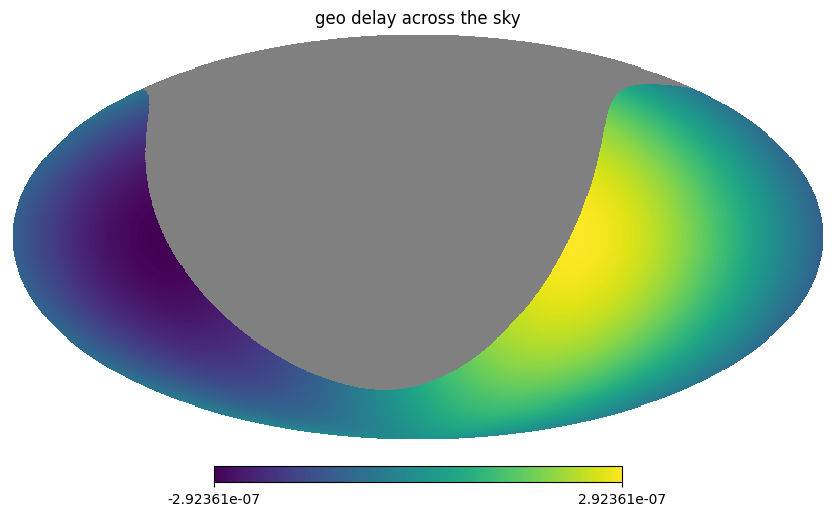

In [72]:
hp.mollview(delays[0], title="geo delay across the sky")

In [105]:
hera_bl_enu[5519]

array([-0.19326754, 50.60720945, -0.41942351])

In [106]:
#what's the expected fringe spacing for this EW baseline?
np.rad2deg(lm/hera_bl_enu[5, 0])*60, np.rad2deg(lm/hera_bl_enu[5519, 1])*60

(np.float64(78.44523457204161), np.float64(135.85996178329532))

expect about 6.138833519258819 cycles per primary beam
expect about 3.637827270671893 cycles per primary beam


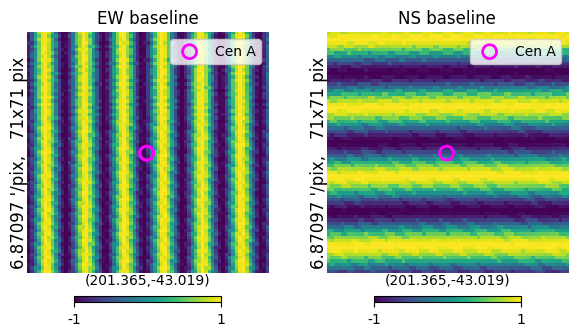

In [135]:
xsize = np.rad2deg(fov)*60/res
fig = plt.figure(figsize=(6, 3))
fringe = np.exp(2j * np.pi * 150e6 * delays[0])
hp.gnomview(fringe.real, rot=(cenA.ra.deg, cenA.dec.deg),reso=res,xsize=xsize,fig=fig.number,sub=(121),title='EW baseline')

hp.projscatter(cenA.ra.deg, cenA.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=2,             # Line width
               label='Cen A')
plt.legend()
print("expect about",xsize*res/80, "cycles per primary beam")
fringe = np.exp(2j * np.pi * 150e6 * delays[1])
hp.gnomview(fringe.real, rot=(cenA.ra.deg, cenA.dec.deg),reso=res,xsize=xsize, fig=fig.number,sub=(122), title='NS baseline')
hp.projscatter(cenA.ra.deg, cenA.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=2,             # Line width
               label='Cen A')
plt.legend()
print("expect about",xsize*res/135, "cycles per primary beam")


expect about 5.153229617726109 cycles
expect about 3.05376569939325 cycles


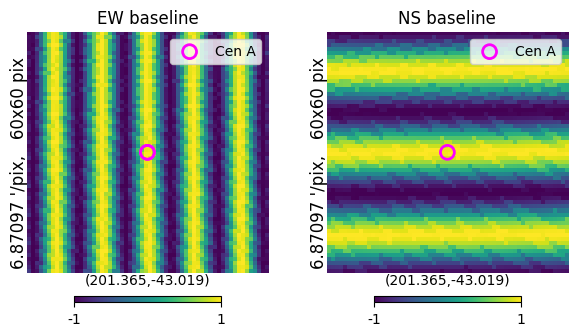

In [136]:
fig = plt.figure(figsize=(6, 3))
fringe = np.exp(2j * np.pi * 150e6 * (delays[0]-delays_cenA[0]))
hp.gnomview(fringe.real, rot=(cenA.ra.deg, cenA.dec.deg),reso=res,xsize=60,fig=fig.number,sub=(121),title='EW baseline')

hp.projscatter(cenA.ra.deg, cenA.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=2,             # Line width
               label='Cen A')
plt.legend()
print("expect about",60*res/80, "cycles")
fringe = np.exp(2j * np.pi * 150e6 * (delays[1]-delays_cenA[1]))
hp.gnomview(fringe.real, rot=(cenA.ra.deg, cenA.dec.deg),reso=res,xsize=60, fig=fig.number,sub=(122),title='NS baseline')
hp.projscatter(cenA.ra.deg, cenA.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=2,             # Line width
               label='Cen A')
plt.legend()
print("expect about",60*res/135, "cycles")


In [137]:
#uvw, w term, PSF